In [ ]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
# ==============================
# 2. LOAD DATASET
# ==============================
import kagglehub

path = kagglehub.dataset_download("omkarmanohardalvi/lungs-disease-dataset-4-types")

dataset_path = os.path.join(path, "Lung Disease Dataset")
print(os.listdir(dataset_path))

Using Colab cache for faster access to the 'lungs-disease-dataset-4-types' dataset.
['val', 'test', 'train']


In [ ]:
# ==============================
# 3. DATA PREPROCESSING
# ==============================
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [ ]:
# ==============================
# 4. LOAD DATA
# ==============================
train_generator = train_datagen.flow_from_directory(
    os.path.join(dataset_path, "train"),
    target_size=(256,256),
    batch_size=32,
    class_mode='categorical'
)

val_generator = test_datagen.flow_from_directory(
    os.path.join(dataset_path, "val"),
    target_size=(256,256),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(dataset_path, "test"),
    target_size=(256,256),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 6054 images belonging to 5 classes.
Found 2016 images belonging to 5 classes.
Found 2025 images belonging to 5 classes.


In [ ]:
# ==============================
# 5. CLASS WEIGHTS
# ==============================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

In [ ]:
# ==============================
# 6. LOAD EFFICIENTNET
# ==============================
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(256,256,3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
# ==============================
# 7. CUSTOM HEAD
# ==============================
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [ ]:
# ==============================
# 8. FREEZE + FINE-TUNE
# ==============================

# Freeze all layers
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze last 100 layers
for layer in base_model.layers[-100:]:
    layer.trainable = True

In [ ]:
# ==============================
# 9. COMPILE
# ==============================
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# ==============================
# 10. CALLBACKS
# ==============================
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

In [ ]:
# ==============================
# 11. TRAIN
# ==============================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 235s 966ms/step - accuracy: 0.3816 - loss: 1.8245 - val_accuracy: 0.6562 - val_loss: 1.0171 - learning_rate: 1.0000e-05
Epoch 2/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 148s 782ms/step - accuracy: 0.6171 - loss: 1.0695 - val_accuracy: 0.7758 - val_loss: 0.6239 - learning_rate: 1.0000e-05
Epoch 3/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 150s 790ms/step - accuracy: 0.6941 - loss: 0.8462 - val_accuracy: 0.8090 - val_loss: 0.5204 - learning_rate: 1.0000e-05
Epoch 4/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 152s 799ms/step - accuracy: 0.7360 - loss: 0.7168 - val_accuracy: 0.8259 - val_loss: 0.4720 - learning_rate: 1.0000e-05
Epoch 5/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 150s 788ms/step - accuracy: 0.7595 - loss: 0.6561 - val_accuracy: 0.8388 - val_loss: 0.4425 - learning_rate: 1.0000e-05
Epoch 6/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 149s 784ms/step - accuracy: 0.7691 - loss: 0.6096 - val_accuracy: 0.8418 - val_loss: 0.4321 - learning_rate: 1.0000e-05
Epoch 7/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# ==============================
# 12. EVALUATE
# ==============================
test_loss, test_accuracy = model.evaluate(test_generator)
print("Test Accuracy:", test_accuracy)

64/64 ━━━━━━━━━━━━━━━━━━━━ 29s 461ms/step - accuracy: 0.8568 - loss: 0.3733
Test Accuracy: 0.8567901253700256


64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 396ms/step


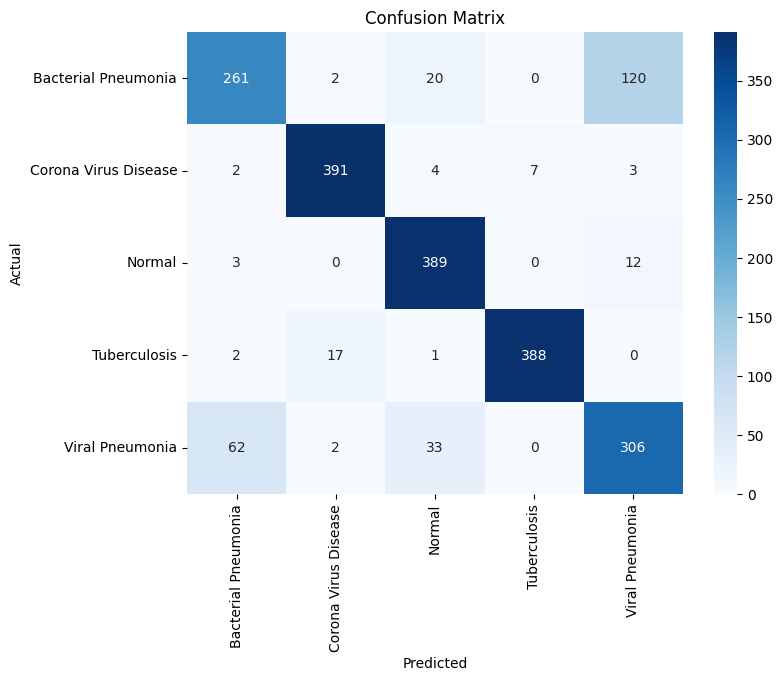

In [ ]:
# ==============================
# 13. CONFUSION MATRIX
# ==============================
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# ==============================
# 14. METRICS
# ==============================
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average='weighted'))
print("Recall:", recall_score(y_true, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))

Accuracy: 0.8567901234567902
Precision: 0.8577643998341749
Recall: 0.8567901234567902
F1 Score: 0.8550393163215227

Classification Report:

                      precision    recall  f1-score   support

 Bacterial Pneumonia       0.79      0.65      0.71       403
Corona Virus Disease       0.95      0.96      0.95       407
              Normal       0.87      0.96      0.91       404
        Tuberculosis       0.98      0.95      0.97       408
     Viral Pneumonia       0.69      0.76      0.73       403

            accuracy                           0.86      2025
           macro avg       0.86      0.86      0.85      2025
        weighted avg       0.86      0.86      0.86      2025

